# Iris Flower Classification

This project trains a machine learning model to classify iris flowers into three species:
Setosa, Versicolor, and Virginica based on their measurements.

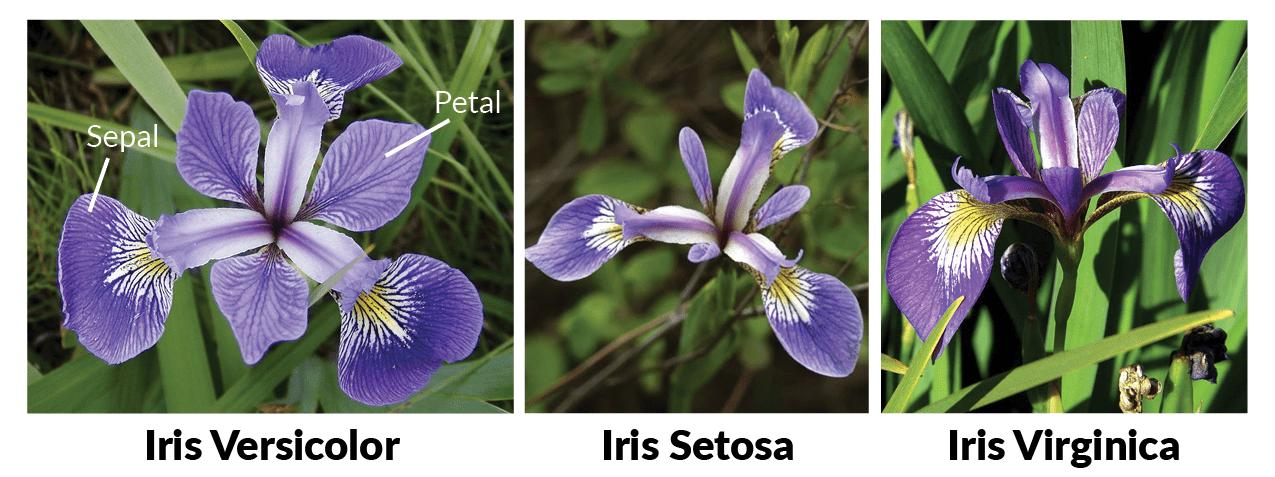

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
#load data
data = pd.read_csv("iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("Columns:", data.columns)
print("\nDataset Info:")
print(data.info())

print("\nUnique Classes:")
print(data['Species'].unique())

Columns: Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Unique Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


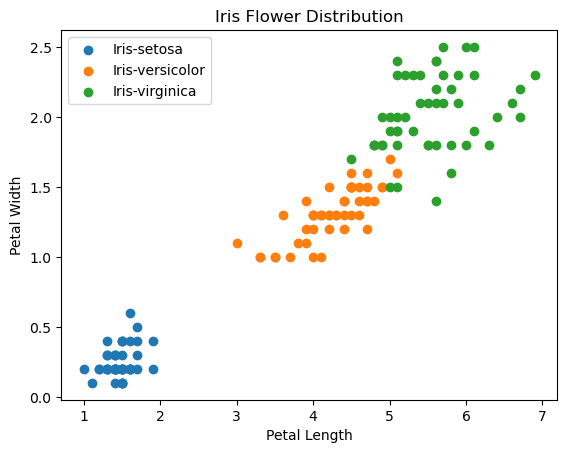

In [8]:
plt.figure()

for flower in data['Species'].unique():
    subset = data[data['Species'] == flower]
    plt.scatter(
        subset['PetalLengthCm'],
        subset['PetalWidthCm'],
        label=flower
    )

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Distribution")
plt.legend()

plt.show()

In [9]:
data['Species'] = data['Species'].astype('category')
data['label'] = data['Species'].cat.codes

print(data[['Species', 'label']].head())

       Species  label
0  Iris-setosa      0
1  Iris-setosa      0
2  Iris-setosa      0
3  Iris-setosa      0
4  Iris-setosa      0


In [10]:
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data['label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#train model KNN
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [13]:
predictions = model.predict(X_test)

correct = (predictions == y_test).sum()
accuracy = correct / len(y_test)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [24]:
sample = np.array([[6,3.4,4.5,1.6]])
result = model.predict(sample)

# Map numeric label back to species name
species_map = dict(enumerate(data['Species'].cat.categories))

print("Predicted Flower:", species_map[result[0]])

Predicted Flower: Iris-versicolor


c:\Users\sandh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [23]:
#multiple input as once 
samples = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 3.4, 4.5, 1.6],
    [6.5, 3.0, 5.5, 2.0]
])

results = model.predict(samples)

for i in range(len(samples)):
    print(samples[i], "→ Predicted:", species_map[results[i]])

[5.1 3.5 1.4 0.2] → Predicted: Iris-setosa
[6.  3.4 4.5 1.6] → Predicted: Iris-setosa
[6.5 3.  5.5 2. ] → Predicted: Iris-setosa


c:\Users\sandh\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
